In [ ]:
import os
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import randint, uniform
from catboost import CatBoostClassifier, Pool
import joblib

print('Imports done')

Imports done


In [ ]:
# Debug & auto-detect processed CSV in Kaggle /kaggle/input folder
import os, zipfile, glob
import pandas as pd

clinical_data_path = '/kaggle/input/liver-clinical-processed'
print("Checking:", clinical_data_path)
print("Exists:", os.path.exists(clinical_data_path))

if not os.path.exists(clinical_data_path):
    # helpful hint for user
    raise FileNotFoundError(
        f"Folder not found: {clinical_data_path}\n"
        "Make sure you added the dataset to this notebook via 'Add data' (top-right -> Add data -> select your dataset)."
    )

# list files and folders inside
items = os.listdir(clinical_data_path)
print("Items found in dataset folder:", items)

# Look for exact file first
expected_name = 'clinical_data_processed.csv'
expected_path = os.path.join(clinical_data_path, expected_name)
if os.path.exists(expected_path):
    print("Found expected file:", expected_path)
    processed_file = expected_path
else:
    # find any CSVs
    csvs = [f for f in items if f.lower().endswith('.csv')]
    if csvs:
        print("CSV files found:", csvs)
        # pick the most likely CSV (you can change selection logic)
        processed_file = os.path.join(clinical_data_path, csvs[0])
        print("Using CSV:", processed_file)
    else:
        # any zip files?
        zips = [f for f in items if f.lower().endswith('.zip')]
        if zips:
            print("ZIP files found:", zips)
            # show content of first zip (no extraction yet)
            zippath = os.path.join(clinical_data_path, zips[0])
            with zipfile.ZipFile(zippath, 'r') as z:
                print("Contents of zip (first 50):", z.namelist()[:50])
            raise FileNotFoundError(
                "No CSV found at dataset root but a ZIP exists. "
                "Either upload the CSV directly to the dataset or unzip the ZIP inside the notebook:\n\n"
                "Example unzip commands:\n"
                "import zipfile\nwith zipfile.ZipFile('/kaggle/input/.../yourfile.zip', 'r') as z:\n    z.extractall('/kaggle/working/your_unzip_folder')\n"
            )
        else:
            raise FileNotFoundError(
                "No CSV or ZIP found in the dataset folder. Double-check the dataset you added to the notebook."
            )

# Load CSV
print("Loading CSV into pandas from:", processed_file)
df = pd.read_csv(processed_file)
print("Loaded df shape:", df.shape)
display(df.head())


Checking: /kaggle/input/liver-clinical-processed
Exists: True
Items found in dataset folder: ['clinical_data_processed.csv']
Found expected file: /kaggle/input/liver-clinical-processed/clinical_data_processed.csv
Loading CSV into pandas from: /kaggle/input/liver-clinical-processed/clinical_data_processed.csv
Loaded df shape: (412, 22)


,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,...,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Ascites_missing,Hepatomegaly_missing,Spiders_missing
0,16.027556,3,1,124.941528,1,2,2,2,3,103.014440,...,52.794521,21.950609,52.539568,49.957522,51.842315,4.2,4.0,0,0,0
1,187.651451,1,1,116.094531,1,1,2,2,1,6.747292,...,18.037671,105.178334,41.257206,20.371681,64.155689,2.6,3.0,0,0,0
2,41.645562,3,1,168.079782,2,1,1,1,2,8.902527,...,71.195205,4.328053,33.212230,8.748673,36.351297,4.0,4.0,0,0,0
3,79.863273,3,1,109.587235,1,1,2,2,2,11.776173,...,21.445205,86.514845,16.831330,21.780531,49.061876,2.3,4.0,0,0,0
4,62.240429,2,3,46.122822,1,1,2,2,1,23.270758,...,48.364726,6.600513,41.086331,14.736283,30.393214,2.9,3.0,0,0,0


In [ ]:
out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# # Configuration / paths
# clinical_data_path = '/kaggle/input/liver-clinical-processed'
# processed_file = os.path.join(clinical_data_path, 'clinical_data_processed.csv')
# random_state = 42
# test_size = 0.20

# print('Processed file expected at:', processed_file)

In [ ]:
# Load preprocessed data
if not os.path.exists(processed_file):
    raise FileNotFoundError(f"Processed file not found: {processed_file}")

df = pd.read_csv(processed_file)
print('Loaded dataframe shape:', df.shape)
print(df.columns.tolist())

# quick peek (if running in notebook UI)
try:
    display(df.head())
except Exception:
    print('Head preview unavailable in this environment.')

Loaded dataframe shape: (412, 22)
['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Ascites_missing', 'Hepatomegaly_missing', 'Spiders_missing']


,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,...,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Ascites_missing,Hepatomegaly_missing,Spiders_missing
0,16.027556,3,1,124.941528,1,2,2,2,3,103.014440,...,52.794521,21.950609,52.539568,49.957522,51.842315,4.2,4.0,0,0,0
1,187.651451,1,1,116.094531,1,1,2,2,1,6.747292,...,18.037671,105.178334,41.257206,20.371681,64.155689,2.6,3.0,0,0,0
2,41.645562,3,1,168.079782,2,1,1,1,2,8.902527,...,71.195205,4.328053,33.212230,8.748673,36.351297,4.0,4.0,0,0,0
3,79.863273,3,1,109.587235,1,1,2,2,2,11.776173,...,21.445205,86.514845,16.831330,21.780531,49.061876,2.3,4.0,0,0,0
4,62.240429,2,3,46.122822,1,1,2,2,1,23.270758,...,48.364726,6.600513,41.086331,14.736283,30.393214,2.9,3.0,0,0,0


In [ ]:
# VERIFICATION: exact column counts and categorical checks
target_col = 'Stage'   # adjust if needed

print("Full dataframe shape (rows, cols):", df.shape)
print("\nAll columns:\n", df.columns.tolist())

# Check for ID (should be dropped)
if 'ID' in df.columns:
    print("\n⚠️ 'ID' column is present. If you intended to drop it, run: df = df.drop(columns=['ID'])")
else:
    print("\n'ID' column not present (good).")


# Ensure the three missing-indicator columns exist; create them if missing (non-destructive)
for base in ['Ascites', 'Hepatomegaly', 'Spiders']:
    miss_col = f"{base}_missing"
    if miss_col not in df.columns:
        print(f"'{miss_col}' not found → creating from original column '{base}' (1 = missing, 0 = not missing).")
        if base in df.columns:
            df[miss_col] = df[base].isna().astype(int)
        else:
            print(f"  Note: original column '{base}' is not present either. Creating {miss_col} as all zeros.")
            df[miss_col] = 0
    else:
        print(f"'{miss_col}' found (ok).")

# Recompute feature list (excluding the target)
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe. Cannot proceed.")
all_features = [c for c in df.columns if c != target_col]
print("\nNumber of features (excluding target):", len(all_features))
print("Features (excluding target):", all_features)

# Build X, y that will be passed to CatBoost
X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int).copy()
print("\nX.shape:", X.shape, "  (rows, features)")
print("y.shape:", y.shape)

# Show dtype + unique counts for transparency
feat_stats = pd.DataFrame({
    'dtype': X.dtypes.astype(str),
    'nunique': [X[c].nunique(dropna=False) for c in X.columns]
})
print("\nFeature dtype and unique counts:")
try:
    display(feat_stats)
except Exception:
    print(feat_stats)

# Identify categorical columns (robust heuristic) and show counts
known_cats = ['Status', 'Drug', 'Sex', 'Edema',
              'Ascites', 'Hepatomegaly', 'Spiders',
              'Ascites_missing', 'Hepatomegaly_missing', 'Spiders_missing']

cat_cols_present = [c for c in known_cats if c in X.columns]
heuristic_obj_cat = [c for c in X.columns if pd.api.types.is_object_dtype(X[c]) or pd.api.types.is_categorical_dtype(X[c])]
heuristic_int_small = [c for c in X.columns if pd.api.types.is_integer_dtype(X[c]) and X[c].nunique() <= 20]

# Merge heuristics while preserving order & uniqueness
cat_cols = []
for c in (cat_cols_present + heuristic_obj_cat + heuristic_int_small):
    if c not in cat_cols:
        cat_cols.append(c)

cat_cols = [c for c in cat_cols if c in X.columns]
print("\nFinal categorical columns (to pass to CatBoost):", cat_cols)
print("Count categorical features:", len(cat_cols))
print("Count numeric features:", X.shape[1] - len(cat_cols))

# Prepare cat_feature_indices for CatBoost (0-based)
cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]
print("Categorical feature indices (0-based):", cat_feature_indices)

# Sanity check
assert X.shape[1] == len(all_features), "Mismatch between computed features and X.columns — investigate."

print("\n✅ Verification complete. Use the printed lists above to confirm you are using all features.")

Full dataframe shape (rows, cols): (412, 22)

All columns:
 ['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Ascites_missing', 'Hepatomegaly_missing', 'Spiders_missing']

'ID' column not present (good).
'Ascites_missing' found (ok).
'Hepatomegaly_missing' found (ok).
'Spiders_missing' found (ok).

Number of features (excluding target): 21
Features (excluding target): ['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Ascites_missing', 'Hepatomegaly_missing', 'Spiders_missing']

X.shape: (412, 21)   (rows, features)
y.shape: (412,)

Feature dtype and unique counts:


,dtype,nunique
N_Days,float64,394
Status,int64,3
Drug,int64,3
Age,float64,344
Sex,int64,2
Ascites,int64,2
Hepatomegaly,int64,2
Spiders,int64,2
Edema,int64,3
Bilirubin,float64,98



Final categorical columns (to pass to CatBoost): ['Status', 'Drug', 'Sex', 'Edema', 'Ascites', 'Hepatomegaly', 'Spiders', 'Ascites_missing', 'Hepatomegaly_missing', 'Spiders_missing']
Count categorical features: 10
Count numeric features: 11
Categorical feature indices (0-based): [1, 2, 4, 8, 5, 6, 7, 18, 19, 20]

✅ Verification complete. Use the printed lists above to confirm you are using all features.


/tmp/ipykernel_37/994345140.py:57: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  heuristic_obj_cat = [c for c in X.columns if pd.api.types.is_object_dtype(X[c]) or pd.api.types.is_categorical_dtype(X[c])]


In [ ]:
# Train / Test split (stratified)
random_state = 42
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (329, 21) Test shape: (83, 21)


In [ ]:
# Compute class weights (optional) and create CatBoost Pools
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Build class weight list indexed by label (0..max_label). This handles nonzero-based labels.
if np.array_equal(classes, np.arange(len(classes))):
    cb_class_weights = class_weights.tolist()
else:
    max_label = int(classes.max())
    weights_full = [1.0] * (max_label + 1)
    for lbl, w in zip(classes, class_weights):
        weights_full[int(lbl)] = float(w)
    cb_class_weights = weights_full

print('CatBoost class weights:', cb_class_weights)

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
eval_pool = Pool(X_test, y_test, cat_features=cat_feature_indices)

CatBoost class weights: [1.0, 4.838235294117647, 1.1267123287671232, 0.6633064516129032, 0.7152173913043478]


In [ ]:
# GPU-awareness + CatBoost GPU usage helper
import os
import subprocess
import sys

def has_nvidia_smi():
    try:
        out = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True, check=True)
        return True, out.stdout.strip()
    except Exception:
        return False, ""

gpu_present, gpu_info = has_nvidia_smi()
print("nvidia-smi available:", gpu_present)
if gpu_present:
    print(gpu_info)

# If you need to re-install CatBoost with GPU support uncomment (careful: takes time).
# On Kaggle usually catboost has GPU support. If you run into errors, try:
# !pip install -q --upgrade catboost

# Choose device string. If you want to use multiple GPUs, set e.g. devices='0,1'
gpu_device = os.environ.get("CUDA_VISIBLE_DEVICES", "0")

# Build helper factory for a CatBoostClassifier with GPU when available
from catboost import CatBoostClassifier

def make_catboost_for_cv(params, use_gpu=gpu_present):
    # params: dict with keys like depth, iterations, learning_rate...
    base_kwargs = dict(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=random_state,
        verbose=0
    )
    # merge user params
    base_kwargs.update(params)
    if use_gpu:
        base_kwargs.update({
            'task_type': 'GPU',
            'devices': str(gpu_device),
            # optionally set 'border_count' smaller/faster on GPU if desired
        })
    return CatBoostClassifier(**base_kwargs)

# Example: test that a tiny model fits on GPU (quick smoke test)
if gpu_present:
    print("Running a tiny GPU fit smoke test (1 iteration)...")
    try:
        tiny = make_catboost_for_cv({'iterations': 1})
        tiny.fit(X_train.iloc[:32], y_train.iloc[:32], cat_features=cat_feature_indices)
        print("Tiny fit finished (GPU should have been used).")
    except Exception as e:
        print("Tiny GPU fit failed:", e)
        print("Falling back to CPU for future fits.")
        gpu_present = False
else:
    print("No GPU detected — CatBoost will run on CPU.")

# ---------------------------------------------------------------------
# If using the manual randomized-search cell: replace model_cv creation with:
# model_cv = make_catboost_for_cv(params)
# ---------------------------------------------------------------------

# And when refitting the final_model, create it like:
def make_final_model(params, use_gpu=gpu_present, verbose=200):
    final_kwargs = dict(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=random_state,
        class_weights=cb_class_weights,
        early_stopping_rounds=100,
        verbose=verbose
    )
    final_kwargs.update(params)
    if use_gpu:
        final_kwargs.update({'task_type': 'GPU', 'devices': str(gpu_device)})
    return CatBoostClassifier(**final_kwargs)

# Example usage in your manual search loop:
# model_cv = make_catboost_for_cv(params)        # per-fold CV
# ...
# final_model = make_final_model(best_params)    # final refit on full train


nvidia-smi available: True
GPU 0: Tesla P100-PCIE-16GB (UUID: GPU-0766a0b5-f4fa-d5af-f623-3eecac192bda)
Running a tiny GPU fit smoke test (1 iteration)...
Tiny fit finished (GPU should have been used).


In [ ]:
# # RANDOMIZED SEARCH: quick hyperparameter tuning (small search)
# # Set do_random_search = True to run. On large datasets this can take time.
# do_random_search = True

# if do_random_search:
#     print('Starting randomized search (n_iter=20)...')
#     param_dist = {
#         'depth': [4, 6, 8, 10],
#         'learning_rate': [0.01, 0.03, 0.05, 0.1],
#         'l2_leaf_reg': [1, 3, 5, 7, 9],
#         'iterations': [200, 500, 800, 1200],
#         'border_count': [32, 64, 128]
#     }
#     base = CatBoostClassifier(
#         loss_function='MultiClass',
#         eval_metric='TotalF1',
#         random_seed=random_state,
#         verbose=0
#     )
#     rsearch = RandomizedSearchCV(
#         estimator=base,
#         param_distributions=param_dist,
#         n_iter=20,
#         scoring='accuracy',
#         cv=3,
#         random_state=random_state,
#         n_jobs=1  # change to -1 if you want parallel runs (may spawn many CatBoost processes)
#     )
#     rsearch.fit(X_train, y_train, cat_features=cat_feature_indices)
#     print('RandomizedSearch best params:', rsearch.best_params_)
#     print('RandomizedSearch best CV score:', rsearch.best_score_)
#     # save results
#     joblib.dump(rsearch.best_estimator_, out_dir / 'catboost_random_search_best.pkl')
#     pd.DataFrame(rsearch.cv_results_).to_csv(out_dir / 'catboost_random_search_results.csv', index=False)
#     best_params = rsearch.best_params_
# else:
#     print('Skipping randomized search. Set do_random_search = True to run.')
#     best_params = None

In [ ]:
# # RANDOMIZED SEARCH (manual) with tqdm progress + Stratified CV (safe for CatBoost cat_features)
# from sklearn.model_selection import ParameterSampler, StratifiedKFold
# from sklearn.metrics import accuracy_score
# from tqdm import tqdm
# import time
# import pandas as pd

# # --- config (change these if you want) ---
# n_iter = 20               # number of random parameter sets to try
# cv_splits = 3             # CV folds
# scoring_name = 'accuracy' # used only for recording; uses sklearn.metrics.accuracy_score now
# random_seed = random_state if 'random_state' in globals() else 42

# param_dist = {
#     'depth': [4, 6, 8, 10],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'l2_leaf_reg': [1, 3, 5, 7, 9],
#     'iterations': [200, 500, 800, 1200],
#     'border_count': [32, 64, 128]
# }

# # Safety checks: make sure required vars exist
# assert 'X_train' in globals() and 'y_train' in globals(), "X_train / y_train not found — run the dataset loading & split cells first."
# assert 'cat_feature_indices' in globals(), "cat_feature_indices not found — run the categorical-detection cell first."

# sampler = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=random_seed))

# results = []  # list of dicts to convert to dataframe
# skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_seed)

# print(f"Running manual randomized search: {n_iter} trials, {cv_splits}-fold CV each")

# for trial_idx, params in enumerate(tqdm(sampler, desc="Trials", unit="trial"), start=1):
#     start_trial = time.time()
#     fold_scores = []
#     fold_times = []
#     # run stratified cv manually so we can pass cat_features to CatBoost.fit
#     for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
#         X_tr = X_train.iloc[tr_idx]
#         y_tr = y_train.iloc[tr_idx]
#         X_val = X_train.iloc[val_idx]
#         y_val = y_train.iloc[val_idx]

#         # Build estimator for this trial (silent during CV)
#         model_cv = CatBoostClassifier(
#             **params,
#             loss_function='MultiClass',
#             eval_metric='TotalF1',
#             random_seed=random_seed,
#             verbose=0
#         )

#         t0 = time.time()
#         model_cv.fit(X_tr, y_tr, cat_features=cat_feature_indices)
#         t1 = time.time()
#         preds = model_cv.predict(X_val)
#         score = accuracy_score(y_val, preds)
#         fold_scores.append(score)
#         fold_times.append(t1 - t0)

#     mean_score = float(np.mean(fold_scores))
#     std_score = float(np.std(fold_scores))
#     mean_fold_time = float(np.mean(fold_times))
#     trial_time = time.time() - start_trial

#     # recording
#     record = {
#         'trial': trial_idx,
#         'params': params,
#         'mean_score': mean_score,
#         'std_score': std_score,
#         'mean_fold_time_sec': mean_fold_time,
#         'trial_time_sec': trial_time
#     }
#     results.append(record)

#     # print a concise per-trial log line (tqdm will also show overall progress)
#     tqdm.write(f"Trial {trial_idx}/{n_iter}: mean {scoring_name}={mean_score:.4f} ± {std_score:.4f} (trial {trial_time:.1f}s) params={params}")

# # Summarize results into DataFrame & save
# results_df = pd.DataFrame([{
#     'trial': r['trial'],
#     **r['params'],
#     'mean_score': r['mean_score'],
#     'std_score': r['std_score'],
#     'mean_fold_time_sec': r['mean_fold_time_sec'],
#     'trial_time_sec': r['trial_time_sec']
# } for r in results])

# results_csv = out_dir / 'catboost_random_search_manual_results.csv'
# results_df.to_csv(results_csv, index=False)
# print("Saved manual randomized-search results to:", results_csv)

# # pick best trial by mean_score
# best_row = results_df.sort_values('mean_score', ascending=False).iloc[0]
# best_params = {k: int(v) if k in ['depth','iterations','l2_leaf_reg','border_count'] and not isinstance(v, bool) else v
#                for k, v in best_row.items() if k in param_dist.keys()}
# print("\nBest trial (by mean CV score):")
# print(best_row.to_dict())

# # Refit best estimator on full training set (with fewer silent logs then verbose enabled)
# print("\nRefitting best estimator on full training set (with early stopping on eval set)...")
# final_params = best_params.copy()
# # keep class weights and a larger iterations default if not present
# final_params.update({
#     'loss_function': 'MultiClass',
#     'eval_metric': 'TotalF1',
#     'random_seed': random_seed,
#     'class_weights': cb_class_weights
# })
# # If tuning used low iterations for speed, you may want to increase final iterations:
# if 'iterations' in final_params and final_params['iterations'] < 1000:
#     final_params['iterations'] = max(1000, final_params['iterations']*2)

# final_model = CatBoostClassifier(**final_params, verbose=200, early_stopping_rounds=100)
# final_model.fit(X_train, y_train, cat_features=cat_feature_indices, eval_set=(X_test, y_test), use_best_model=True)

# # save final model
# final_model_path = out_dir / 'catboost_random_search_manual_best.cbm'
# final_model.save_model(str(final_model_path))
# joblib.dump(final_model, out_dir / 'catboost_random_search_manual_best_joblib.pkl')
# print("Saved best model to:", final_model_path)


Running manual randomized search: 20 trials, 3-fold CV each


Trials:   5%|▌         | 1/20 [00:16<05:20, 16.89s/trial]

Trial 1/20: mean accuracy=0.4863 ± 0.0162 (trial 16.9s) params={'learning_rate': 0.01, 'l2_leaf_reg': 9, 'iterations': 500, 'depth': 8, 'border_count': 128}


Trials:  10%|█         | 2/20 [00:35<05:24, 18.05s/trial]

Trial 2/20: mean accuracy=0.5106 ± 0.0224 (trial 18.9s) params={'learning_rate': 0.03, 'l2_leaf_reg': 9, 'iterations': 1200, 'depth': 6, 'border_count': 64}


...

Trials:  95%|█████████▌| 19/20 [12:02<00:33, 33.82s/trial]

Trial 19/20: mean accuracy=0.5137 ± 0.0135 (trial 24.8s) params={'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 1200, 'depth': 6, 'border_count': 128}


Trials: 100%|██████████| 20/20 [13:00<00:00, 39.02s/trial]

Trial 20/20: mean accuracy=0.4924 ± 0.0184 (trial 57.7s) params={'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 10, 'border_count': 128}


NameError: name 'out_dir' is not defined

In [ ]:
# # Train final CatBoost model (uses best_params from RandomizedSearch if available)
# model_params = dict(
#     iterations=2000,
#     learning_rate=0.05,
#     depth=6,
#     loss_function='MultiClass',
#     eval_metric='TotalF1',
#     random_seed=random_state,
#     verbose=200,
#     early_stopping_rounds=100,
#     l2_leaf_reg=3,
#     class_weights=cb_class_weights
# )

# # If tuning produced params, apply them (but preserve class_weights and early stopping)
# if 'best_params' in globals() and best_params is not None:
#     print('Applying tuned hyperparameters from RandomizedSearch to model_params (overriding defaults)')
#     # only copy relevant keys (ignore ones we explicitly want to keep)
#     for k, v in best_params.items():
#         model_params[k] = v
#     # ensure class_weights and early stopping remain present
#     model_params['class_weights'] = cb_class_weights

# print('Final model parameters:') 
# print(model_params)

# model = CatBoostClassifier(**model_params)
# print('Starting CatBoost training...')
# start_time = time.time()
# model.fit(train_pool, eval_set=eval_pool, use_best_model=True)
# train_time = time.time() - start_time
# print(f'Finished training in {train_time/60:.2f} minutes')
# print('Best iteration:', model.get_best_iteration())

In [ ]:
# # Recompute class weights robustly and run final training
# import numpy as np
# from sklearn.utils.class_weight import compute_class_weight

# # get unique classes (sorted) from training labels
# classes = np.unique(y_train)
# n_classes = len(classes)
# print("Detected classes (sorted):", classes, "n_classes:", n_classes)

# # compute balanced weights for these class labels
# weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
# # map to a list in the order CatBoost expects: weights[i] corresponds to classes[i]
# class_weights_list = [float(w) for w in weights]
# print("Computed class weights (in label order):")
# for lbl, w in zip(classes, class_weights_list):
#     print(f"  label {lbl}: weight {w:.6f}")

# # Now set cb_class_weights to this list (overwrite previous possibly-bad value)
# cb_class_weights = class_weights_list

# # Sanity check for CatBoost: length must equal number of classes
# assert len(cb_class_weights) == n_classes, f"Length mismatch after recompute: {len(cb_class_weights)} vs {n_classes}"

# # --- Now train the final model (GPU-aware helper if available) ---
# # Build final params (you can reuse your tuned best_params if available)
# final_model_params = dict(
#     iterations=2000,
#     learning_rate=0.05,
#     depth=6,
#     loss_function='MultiClass',
#     eval_metric='TotalF1',
#     random_seed=random_state if 'random_state' in globals() else 42,
#     early_stopping_rounds=100,
#     l2_leaf_reg=3,
#     class_weights=cb_class_weights
# )
# # apply best_params if present
# if 'best_params' in globals() and best_params is not None:
#     final_model_params.update(best_params)
#     final_model_params['class_weights'] = cb_class_weights

# print("\nFinal training params preview:", {k: final_model_params[k] for k in list(final_model_params)[:10]})

# # Prefer helper if available (handles GPU)
# if 'make_final_model' in globals():
#     try:
#         model = make_final_model(final_model_params, use_gpu=True, verbose=100)
#         print("Using make_final_model() helper (GPU if available).")
#     except Exception as e:
#         print("make_final_model failed or GPU not available, falling back to manual construction. Error:", e)
#         from catboost import CatBoostClassifier
#         model = CatBoostClassifier(**final_model_params, verbose=100)
# else:
#     from catboost import CatBoostClassifier
#     model = CatBoostClassifier(**final_model_params, verbose=100)

# # Fit with visible logs
# print("\nStarting final training...")
# model.fit(X_train, y_train, cat_features=cat_feature_indices, eval_set=(X_test, y_test), use_best_model=True, verbose=100)

# print("\nBest iteration:", model.get_best_iteration())
# try:
#     print("Best score:", model.get_best_score())
# except Exception:
#     pass

# # Save model
# out_dir = Path('outputs')
# out_dir.mkdir(parents=True, exist_ok=True)
# model_path = out_dir / 'catboost_clinical_final_fixed_class_weights.cbm'
# model.save_model(str(model_path))
# print("Saved model to:", model_path)


Detected classes (sorted): [1 2 3 4] n_classes: 4
Computed class weights (in label order):
  label 1: weight 4.838235
  label 2: weight 1.126712
  label 3: weight 0.663306
  label 4: weight 0.715217

Final training params preview: {'iterations': 2000, 'learning_rate': 0.05, 'depth': 6, 'loss_function': 'MultiClass', 'eval_metric': 'TotalF1', 'random_seed': 42, 'early_stopping_rounds': 100, 'l2_leaf_reg': 3, 'class_weights': [4.838235294117647, 1.1267123287671232, 0.6633064516129032, 0.7152173913043478]}
Using make_final_model() helper (GPU if available).

Starting final training...
0:	learn: 0.6467854	test: 0.3493768	best: 0.3493768 (0)	total: 786ms	remaining: 26m 10s
100:	learn: 0.9255696	test: 0.2931107	best: 0.4719361 (12)	total: 1.6s	remaining: 30.2s
bestTest = 0.4719361022
bestIteration = 12
Shrink model to first 13 iterations.

Best iteration: 12
Best score: {'learn': {'TotalF1': 0.9310480603420662, 'MultiClass': 0.5459454661082351}, 'validation': {'TotalF1': 0.47193610224083216,

Detected classes (sorted): [1 2 3 4] n_classes: 4
Class weights (clipped max=3.0):
  label 1: weight 3.000000
  label 2: weight 1.126712
  label 3: weight 0.663306
  label 4: weight 0.715217
Training set size before: 329, after oversampling tiny class: 344

Starting final training...
0:	learn: 0.5105717	test: 0.3405288	best: 0.3405288 (0)	total: 13.5ms	remaining: 27.1s
100:	learn: 0.8649814	test: 0.4490738	best: 0.5192368 (47)	total: 749ms	remaining: 14.1s
200:	learn: 0.9635533	test: 0.4656920	best: 0.5192368 (47)	total: 1.52s	remaining: 13.6s
Stopped by overfitting detector  (250 iterations wait)

bestTest = 0.5192367655
bestIteration = 47

Shrink model to first 48 iterations.

Best iteration: 47
Best score: {'learn': {'TotalF1': 0.9900051664007486, 'MultiClass': 0.2677205626927405}, 'validation': {'TotalF1': 0.5192367655271333, 'MultiClass': 1.1325969622314769}}

Test accuracy: 0.5060

Classification report:
              precision    recall  f1-score   support

           1     0.33

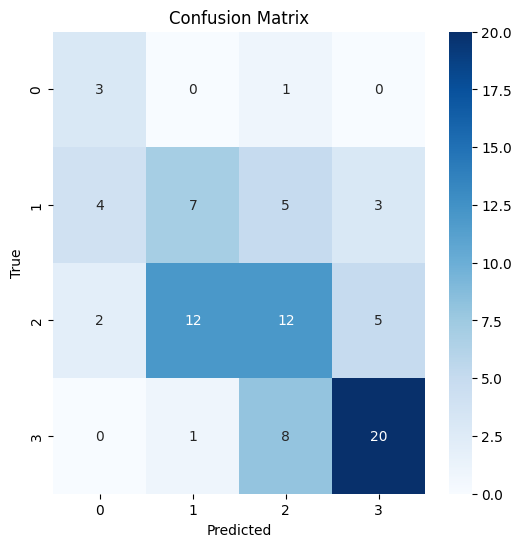

Top features:
                  feature  importance
6           Hepatomegaly   11.774671
1                 Status   10.223569
14                  SGOT    8.153355
11               Albumin    7.929112
15         Tryglicerides    7.805042
16             Platelets    7.653440
3                    Age    7.338693
10           Cholesterol    7.242828
0                 N_Days    6.458984
12                Copper    5.963672
13              Alk_Phos    5.142468
17           Prothrombin    4.635796
9              Bilirubin    4.167640
8                  Edema    2.512222
7                Spiders    1.165000
20       Spiders_missing    0.654495
18       Ascites_missing    0.436383
2                   Drug    0.429090
19  Hepatomegaly_missing    0.240376
5                Ascites    0.073164


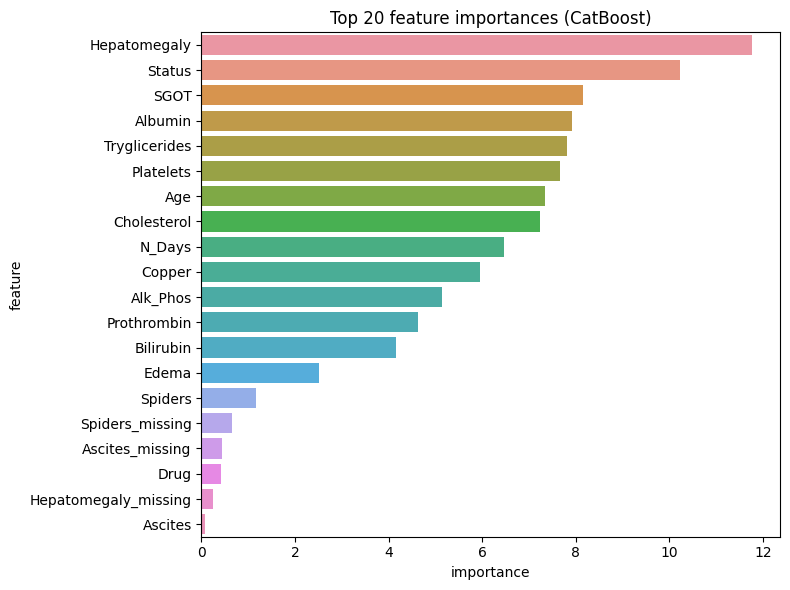

Saved CatBoost model to outputs/catboost_clinical_final_nextlevel.cbm
Saved joblib to outputs/catboost_clinical_final_nextlevel_joblib.pkl


In [ ]:
# ======================================================
# CatBoost Training – Next Level Balanced Setup
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import shuffle

from catboost import CatBoostClassifier, Pool

# ---------------------------
# 1. Compute class weights (clipped)
# ---------------------------
classes = np.unique(y_train)
n_classes = len(classes)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_list = [min(float(w), 3.0) for w in weights]  # clip max to 3

print("Detected classes (sorted):", classes, "n_classes:", n_classes)
print("Class weights (clipped max=3.0):")
for lbl, w in zip(classes, class_weights_list):
    print(f"  label {lbl}: weight {w:.6f}")

# ---------------------------
# 2. Slightly oversample tiny class 1
# ---------------------------
cls = 1
cls_idx = np.where(y_train == cls)[0]
n_to_add = 15  # slightly more than before

X_extra = X_train.iloc[cls_idx].sample(n=n_to_add, replace=True, random_state=42)
y_extra = y_train.iloc[cls_idx].sample(n=n_to_add, replace=True, random_state=42)

X_train_res = pd.concat([X_train, X_extra], axis=0)
y_train_res = pd.concat([y_train, y_extra], axis=0)

# Shuffle
X_train_res, y_train_res = shuffle(X_train_res, y_train_res, random_state=42)
print(f"Training set size before: {X_train.shape[0]}, after oversampling tiny class: {X_train_res.shape[0]}")

# ---------------------------
# 3. CatBoost parameters
# ---------------------------
final_model_params = dict(
    iterations=2000,
    learning_rate=0.07,  # slightly higher for faster convergence
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=42,
    l2_leaf_reg=3,
    class_weights=class_weights_list,
    early_stopping_rounds=250,
    verbose=100
)

# ---------------------------
# 4. Construct model
# ---------------------------
model = CatBoostClassifier(**final_model_params)

# ---------------------------
# 5. Prepare Pools
# ---------------------------
train_pool = Pool(X_train_res, y_train_res, cat_features=cat_feature_indices)
eval_pool = Pool(X_test, y_test, cat_features=cat_feature_indices)

# ---------------------------
# 6. Fit model
# ---------------------------
print("\nStarting final training...")
model.fit(train_pool, eval_set=eval_pool, use_best_model=True)

print("\nBest iteration:", model.get_best_iteration())
try:
    print("Best score:", model.get_best_score())
except Exception:
    pass

# ---------------------------
# 7. Evaluation
# ---------------------------
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'\nTest accuracy: {acc:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print('\nConfusion matrix:')
print(cm)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ---------------------------
# 8. Feature importance
# ---------------------------
fi = model.get_feature_importance(train_pool, type='FeatureImportance')
fi_df = pd.DataFrame({'feature': X.columns, 'importance': fi}).sort_values('importance', ascending=False)
print('Top features:\n', fi_df.head(20))
fi_df.to_csv(Path('outputs') / 'catboost_feature_importance_nextlevel.csv', index=False)

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=fi_df.head(20))
plt.title('Top 20 feature importances (CatBoost)')
plt.tight_layout()
plt.show()

# ---------------------------
# 9. Save model
# ---------------------------
out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)

model_path = out_dir / 'catboost_clinical_final_nextlevel.cbm'
model.save_model(str(model_path))
print('Saved CatBoost model to', model_path)

joblib.dump(model, out_dir / 'catboost_clinical_final_nextlevel_joblib.pkl')
print('Saved joblib to', out_dir / 'catboost_clinical_final_nextlevel_joblib.pkl')


Test accuracy: 0.4940

Classification report:
              precision    recall  f1-score   support

           1     0.1333    0.5000    0.2105         4
           2     0.3529    0.3158    0.3333        19
           3     0.5000    0.2903    0.3673        31
           4     0.7273    0.8276    0.7742        29

    accuracy                         0.4940        83
   macro avg     0.4284    0.4834    0.4214        83
weighted avg     0.5281    0.4940    0.4942        83


Confusion matrix:
[[ 2  2  0  0]
 [ 4  6  6  3]
 [ 9  7  9  6]
 [ 0  2  3 24]]


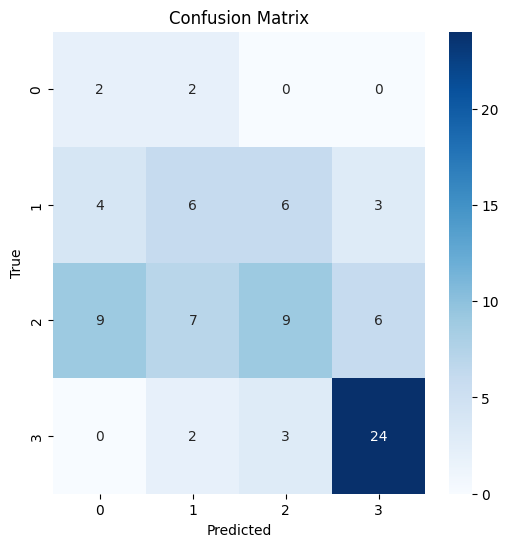

Top features:
                  feature  importance
6           Hepatomegaly   17.759114
0                 N_Days   15.160092
3                    Age    9.574362
16             Platelets    9.079067
17           Prothrombin    7.294469
10           Cholesterol    7.115420
12                Copper    6.982780
13              Alk_Phos    6.818152
11               Albumin    6.646024
15         Tryglicerides    6.561063
14                  SGOT    5.005971
9              Bilirubin    1.106063
7                Spiders    0.897424
4                    Sex    0.000000
2                   Drug    0.000000
1                 Status    0.000000
8                  Edema    0.000000
5                Ascites    0.000000
18       Ascites_missing    0.000000
19  Hepatomegaly_missing    0.000000


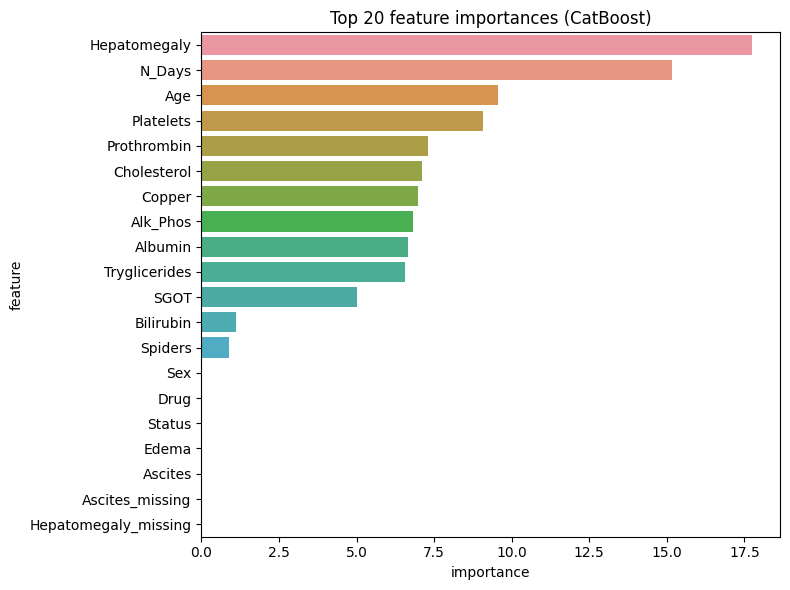

Saved CatBoost model to outputs/catboost_clinical_final.cbm
Saved joblib to outputs/catboost_clinical_final_joblib.pkl


In [ ]:
# Evaluation on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

print('\nConfusion matrix:')
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot confusion matrix
try:
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
except Exception as e:
    print('Could not plot confusion matrix:', e)

# Feature importance
fi = model.get_feature_importance(train_pool, type='FeatureImportance')
fi_df = pd.DataFrame({'feature': X.columns, 'importance': fi}).sort_values('importance', ascending=False)
print('Top features:\n', fi_df.head(20))
fi_df.to_csv(out_dir / 'catboost_feature_importance.csv', index=False)

# Plot top-20
plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=fi_df.head(20))
plt.title('Top 20 feature importances (CatBoost)')
plt.tight_layout()
plt.show()

# Save model
model_path = out_dir / 'catboost_clinical_final.cbm'
model.save_model(str(model_path))
print('Saved CatBoost model to', model_path)

# Save joblib
joblib.dump(model, out_dir / 'catboost_clinical_final_joblib.pkl')
print('Saved joblib to', out_dir / 'catboost_clinical_final_joblib.pkl')

In [ ]:
# Optional: Stratified K-fold cross validation (commented out)
# Uncomment and run if you want CV evaluation.
#
# n_splits = 5
# skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
# cv_scores = []
# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#     print('\nFold', fold+1)
#     X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#     pool_tr = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
#     pool_val = Pool(X_val, y_val, cat_features=cat_feature_indices)
#     cb = CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=6, random_seed=random_state, verbose=200, early_stopping_rounds=50)
#     cb.fit(pool_tr, eval_set=pool_val, use_best_model=True)
#     preds = cb.predict(X_val)
#     acc = accuracy_score(y_val, preds)
#     print('Fold acc:', acc)
#     cv_scores.append(acc)
# print('\nCV mean acc:', np.mean(cv_scores), 'std:', np.std(cv_scores))


In [ ]:
print('Notebook run complete.')